In [1]:
from datetime import datetime
import logging

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from tqdm import tqdm

import torchvision
from torchvision import datasets
from torchvision.transforms import Compose, ToTensor, Normalize, Resize

import matplotlib.pyplot as plt
import numpy as np

# Print versions of libraries
print(f"PyTorch version: {torch.__version__}\ntorchvision version: {torchvision.__version__}")


PyTorch version: 2.4.1+cu121
torchvision version: 0.19.1+cu121


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}\t" + (f"{torch.cuda.get_device_name(0)}" if torch.cuda.is_available() else "CPU"))

Using device: cuda	Tesla T4


In [3]:
transform = Compose([
    Resize(28),
    ToTensor()
])

train_data = datasets.MNIST(root="../MNIST_data", train=True, download=True, transform=transform)
test_data = datasets.MNIST(root="../MNIST_data", train=False, download=True, transform=transform)

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 9912422/9912422 [00:00<00:00, 38640537.38it/s]


Extracting ../MNIST_data/MNIST/raw/train-images-idx3-ubyte.gz to ../MNIST_data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 28881/28881 [00:00<00:00, 1201040.00it/s]


Extracting ../MNIST_data/MNIST/raw/train-labels-idx1-ubyte.gz to ../MNIST_data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 1648877/1648877 [00:00<00:00, 10639145.47it/s]


Extracting ../MNIST_data/MNIST/raw/t10k-images-idx3-ubyte.gz to ../MNIST_data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 4542/4542 [00:00<00:00, 9759492.20it/s]

Extracting ../MNIST_data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ../MNIST_data/MNIST/raw



In [4]:
print(f"Train dataset size: {len(train_data)}")
print(f"Test dataset size: {len(test_data)}")

Train dataset size: 60000
Test dataset size: 10000


In [5]:
from torch.utils.data import DataLoader
BATCH_SIZE = 64
train_dataloader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=True
)
test_dataloader = DataLoader(
    test_data,
    batch_size=BATCH_SIZE,
    shuffle=False
)

## GAN Models

In [6]:
# Generator network class
class Generator(nn.Module):
    def __init__(self, g_input_dim, g_output_dim):
        super(Generator, self).__init__()       
        self.fc1 = nn.Linear(g_input_dim, 256)
        self.fc2 = nn.Linear(self.fc1.out_features, self.fc1.out_features*2)
        self.fc3 = nn.Linear(self.fc2.out_features, self.fc2.out_features*2)
        self.fc4 = nn.Linear(self.fc3.out_features, g_output_dim)
    
    # forward method
    def forward(self, x): 
        x = F.leaky_relu(self.fc1(x), 0.2)
        x = F.leaky_relu(self.fc2(x), 0.2)
        x = F.leaky_relu(self.fc3(x), 0.2)
        return torch.tanh(self.fc4(x))

In [7]:
# Discriminator network class
class Discriminator(nn.Module):
    def __init__(self, d_input_dim):
        super(Discriminator, self).__init__()
        self.fc1 = nn.Linear(d_input_dim, 1024)
        self.fc2 = nn.Linear(self.fc1.out_features, self.fc1.out_features//2)
        self.fc3 = nn.Linear(self.fc2.out_features, self.fc2.out_features//2)
        self.fc4 = nn.Linear(self.fc3.out_features, 1)
    
    # forward method
    def forward(self, x):
        x = F.leaky_relu(self.fc1(x), 0.2)
        x = F.dropout(x, 0.3)
        x = F.leaky_relu(self.fc2(x), 0.2)
        x = F.dropout(x, 0.3)
        x = F.leaky_relu(self.fc3(x), 0.2)
        x = F.dropout(x, 0.3)
        return torch.sigmoid(self.fc4(x))

In [8]:
# Initialize models
mnist_dim = 28*28
latent_dim = 100

discriminator = Discriminator(mnist_dim).to(device)
generator = Generator(latent_dim, mnist_dim).to(device)

In [9]:
discriminator

Discriminator(
  (fc1): Linear(in_features=784, out_features=1024, bias=True)
  (fc2): Linear(in_features=1024, out_features=512, bias=True)
  (fc3): Linear(in_features=512, out_features=256, bias=True)
  (fc4): Linear(in_features=256, out_features=1, bias=True)
)

In [10]:
generator

Generator(
  (fc1): Linear(in_features=100, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=512, bias=True)
  (fc3): Linear(in_features=512, out_features=1024, bias=True)
  (fc4): Linear(in_features=1024, out_features=784, bias=True)
)

In [11]:
# Set random seed for reproducibility
torch.manual_seed(42)

# Configuration
learning_rate = 0.0002

# Setup optimizers
d_optimizer = Adam(discriminator.parameters(), lr=learning_rate)
g_optimizer = Adam(generator.parameters(), lr=learning_rate)

# Loss function
criterion = nn.BCELoss()

In [12]:
from torch.autograd import Variable

discrimination_losses = []
generation_losses = []

epochs = 200
for epoch in range(1, epochs + 1):
    D_losses, G_losses = [], []

    # Progress bar for the current epoch
    pbar = tqdm(train_dataloader, desc=f"Epoch {epoch}/{epochs}")

    for real_images, _ in pbar:
        # ------------------------------
        # Train the discriminator (D)
        # ------------------------------
        discriminator.zero_grad()

        # Train discriminator on real data
        real_images = real_images.view(-1, mnist_dim)
        real_labels = torch.ones(real_images.size(0), 1)
        real_images, real_labels = Variable(real_images.to(device)), Variable(real_labels.to(device))

        d_output_real = discriminator(real_images)
        d_loss_real = criterion(d_output_real, real_labels)

        # Train discriminator on fake data
        noise = Variable(torch.randn(real_images.size(0), latent_dim).to(device))
        fake_images = generator(noise)
        fake_labels = torch.zeros(real_images.size(0), 1).to(device)

        d_output_fake = discriminator(fake_images)
        d_loss_fake = criterion(d_output_fake, fake_labels)

        # Compute total discriminator loss
        d_loss = d_loss_real + d_loss_fake
        d_loss.backward()
        d_optimizer.step()

        # Store discriminator loss
        D_losses.append(d_loss.item())

        # ------------------------------
        # Train the generator (G)
        # ------------------------------
        generator.zero_grad()

        noise = Variable(torch.randn(real_images.size(0), latent_dim).to(device))
        gen_labels = torch.ones(real_images.size(0), 1).to(device)

        fake_images = generator(noise)
        d_output = discriminator(fake_images)
        g_loss = criterion(d_output, gen_labels)
        g_loss.backward()
        g_optimizer.step()

        # Store generator loss
        G_losses.append(g_loss.item())

        # Update progress bar with current losses
        pbar.set_postfix({
            'D_loss': f'{d_loss.item():.4f}',
            'G_loss': f'{g_loss.item():.4f}'
        })

    # Print epoch results
    print('[%d/%d]: loss_d: %.3f, loss_g: %.3f' % (
        epoch, epochs,
        torch.mean(torch.FloatTensor(D_losses)),
        torch.mean(torch.FloatTensor(G_losses))
    ))
    discrimination_losses.append(sum(D_losses) / len(D_losses))
    generation_losses.append(sum(G_losses) / len(G_losses))


Epoch 1/200: 100%|██████████| 938/938 [00:14<00:00, 62.90it/s, D_loss=1.1121, G_loss=2.3066]


[1/200]: loss_d: 1.271, loss_g: 1.444


Epoch 2/200: 100%|██████████| 938/938 [00:14<00:00, 64.28it/s, D_loss=0.1774, G_loss=3.5117]


[2/200]: loss_d: 0.856, loss_g: 2.183


Epoch 3/200: 100%|██████████| 938/938 [00:14<00:00, 65.27it/s, D_loss=0.4830, G_loss=1.8720]


...

[198/200]: loss_d: 0.368, loss_g: 3.431


Epoch 199/200: 100%|██████████| 938/938 [00:14<00:00, 65.62it/s, D_loss=0.4971, G_loss=3.5177]


[199/200]: loss_d: 0.370, loss_g: 3.425


Epoch 200/200: 100%|██████████| 938/938 [00:14<00:00, 64.96it/s, D_loss=0.5758, G_loss=3.3301]

[200/200]: loss_d: 0.386, loss_g: 3.326


In [13]:
# Save final models
torch.save(generator.state_dict(), 'generator_final.pth')
torch.save(discriminator.state_dict(), 'discriminator_final.pth')

# # save discrimination_losses and test generation_losses
np.save('discrimination_losses.npy', np.array(discrimination_losses))
np.save('generation_losses.npy', np.array(generation_losses))

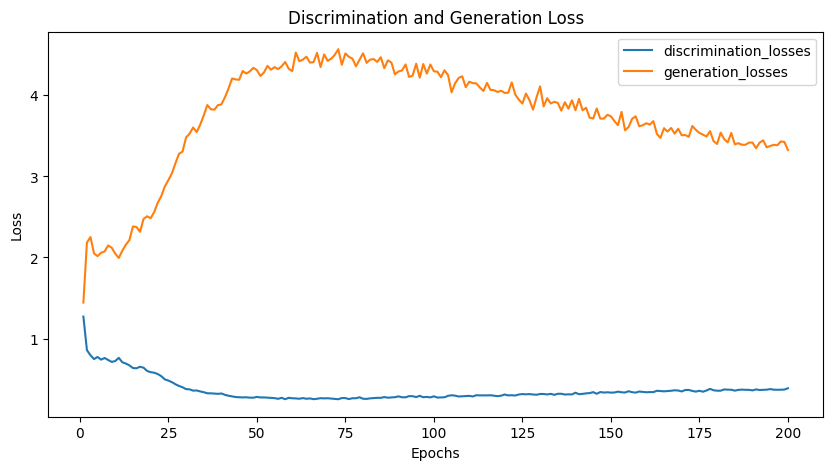

In [14]:
epochs = range(1, 201) 

plt.figure(figsize=(10, 5))
plt.plot(epochs, discrimination_losses, label='discrimination_losses')
plt.plot(epochs, generation_losses, label='generation_losses')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Discrimination and Generation Loss')
plt.legend()
plt.show()

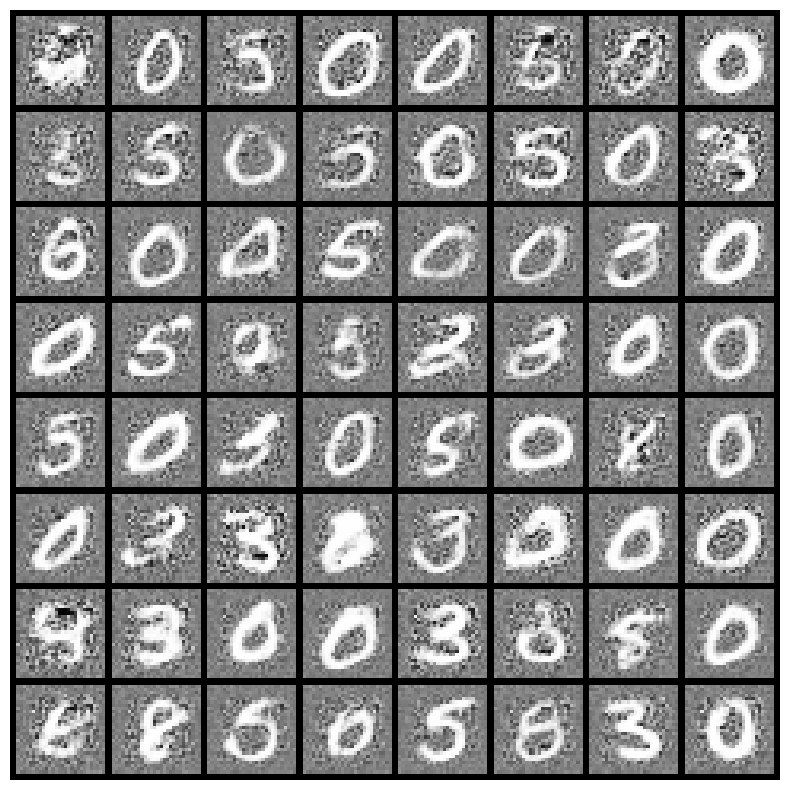

In [15]:
from torchvision.utils import save_image
from torchvision.utils import make_grid
from torch.autograd import Variable

with torch.no_grad():
    test_z = Variable(torch.randn(64, latent_dim).to(device))
    generated = generator(test_z)
    
    grid = make_grid(generated.view(generated.size(0), 1, 28, 28), nrow=8, normalize=True)
    plt.figure(figsize=(10, 10))
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
    plt.axis('off')
    plt.show()
    save_image(generated.view(generated.size(0), 1, 28, 28), 'output' + '.png')

# Evaluate

In [16]:
from torchvision import transforms
transform = transforms.Compose([
        transforms.Grayscale(3),  # Chuyển từ 1 channel sang 3 channels
        transforms.Resize((299, 299)),  # Resize về 299x299
        transforms.ToTensor(),  # Chuyển đổi sang tensor
    ])

In [17]:
from torch.utils.data import Subset

# Tải toàn bộ test set của MNIST
test_set = datasets.MNIST('../MNIST_data', train=False, download=False, transform=transform)

# Chọn 1000 ảnh đầu tiên từ test_set
subset_indices = list(range(1000))
test_subset = Subset(test_set, subset_indices)

# Tạo DataLoader từ phần subset này
test_loader = torch.utils.data.DataLoader(test_subset, BATCH_SIZE, shuffle=False)

In [18]:
def generate_random_images(n=1000, transform=transform):
    generator.eval()
    images = []
    
    with torch.no_grad():
        for _ in range(n):
            z = torch.randn(1, latent_dim).to(device)
            generated_image = generator(z)
            generated_image = torch.sigmoid(generated_image).cpu().squeeze().view(1, 28, 28)  # Reshape to (C, H, W)
            
            # Convert tensor to PIL Image for transformations
            pil_image = transforms.functional.to_pil_image(generated_image)
            transformed_image = transform(pil_image)
            images.append(transformed_image)
    
    # Stack the images into a tensor
    return torch.stack(images)

# Generate 1000 random images with transform
generated_images = generate_random_images(1000, transform)


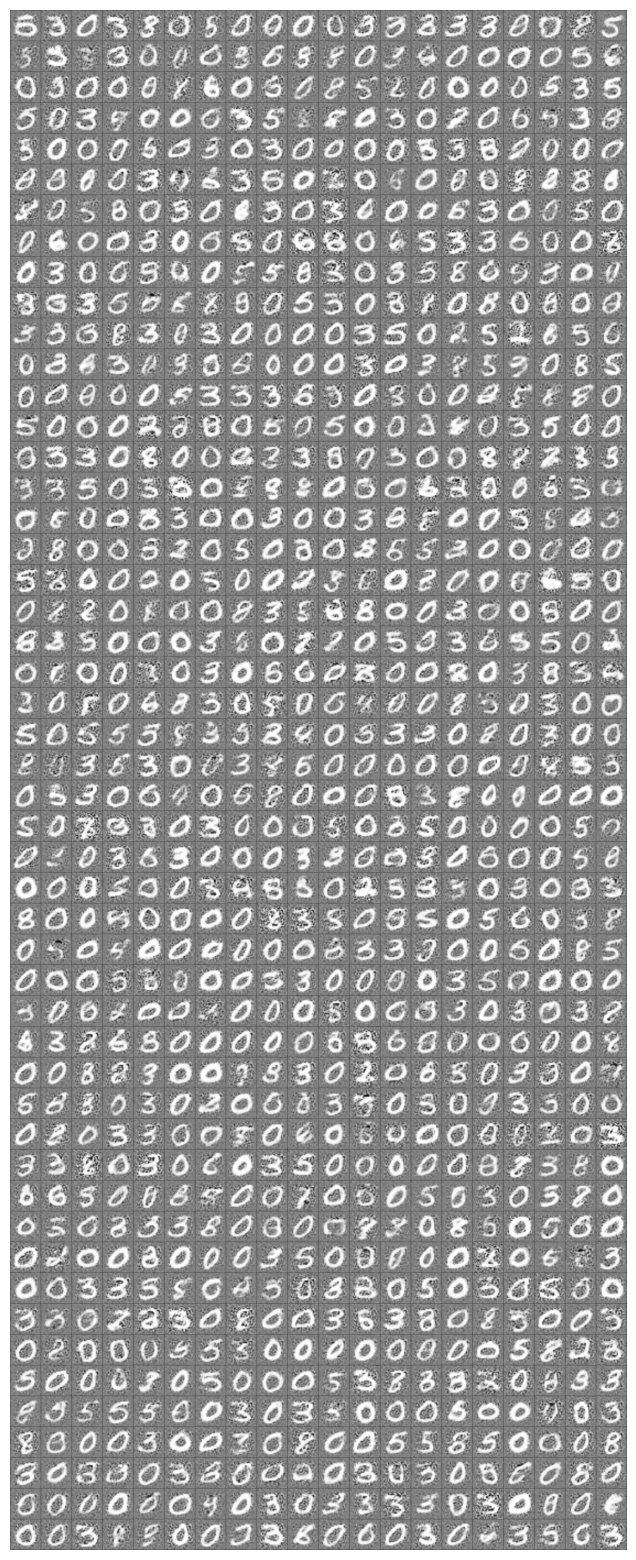

In [19]:
# prompt: show ảnh vừa được tạo ra

import matplotlib.pyplot as plt
from torchvision.utils import make_grid

# Assuming 'generated_images' is the tensor containing the generated images

grid = make_grid(generated_images, nrow=20, normalize=True)
plt.figure(figsize=(20, 20))
plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
plt.axis('off')
plt.show()

In [20]:
test_images = []
test_labels = []
for images, labels in test_loader:
    test_images.append(images)
    test_labels.append(labels)

# Ghép các ảnh lại thành một tensor duy nhất
test_images = torch.cat(test_images)[:1000]

In [21]:
test_images.shape, generated_images.shape

(torch.Size([1000, 3, 299, 299]), torch.Size([1000, 3, 299, 299]))

In [22]:
!pip install torchmetrics Torch-fidelity

In [23]:
import torchmetrics
from torchmetrics.image.fid import FrechetInceptionDistance

# Chuyển toàn bộ hoạt động sang CPU
device = torch.device('cpu')

# Đảm bảo rằng `fid` đang ở trên device là CPU
fid = FrechetInceptionDistance(feature=2048).to(device)

test_images = (test_images * 255).to(torch.uint8).to(device)  # Chuyển ảnh sang CPU

# Cập nhật ảnh thật vào FID
fid.update(test_images, real=True)

# Chuyển ảnh sinh ra sang dạng phù hợp và đảm bảo ảnh cũng nằm trên CPU
generated_images = (generated_images * 255).to(torch.uint8).to(device)  # Chuyển ảnh sinh ra sang CPU

# Cập nhật ảnh sinh ra vào FID
fid.update(generated_images, real=False)

# Tính FID
fid_score = fid.compute()
print(f"FID Score: {fid_score}")

Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 300MB/s]


FID Score: 243.87753295898438
